## Enhancement test

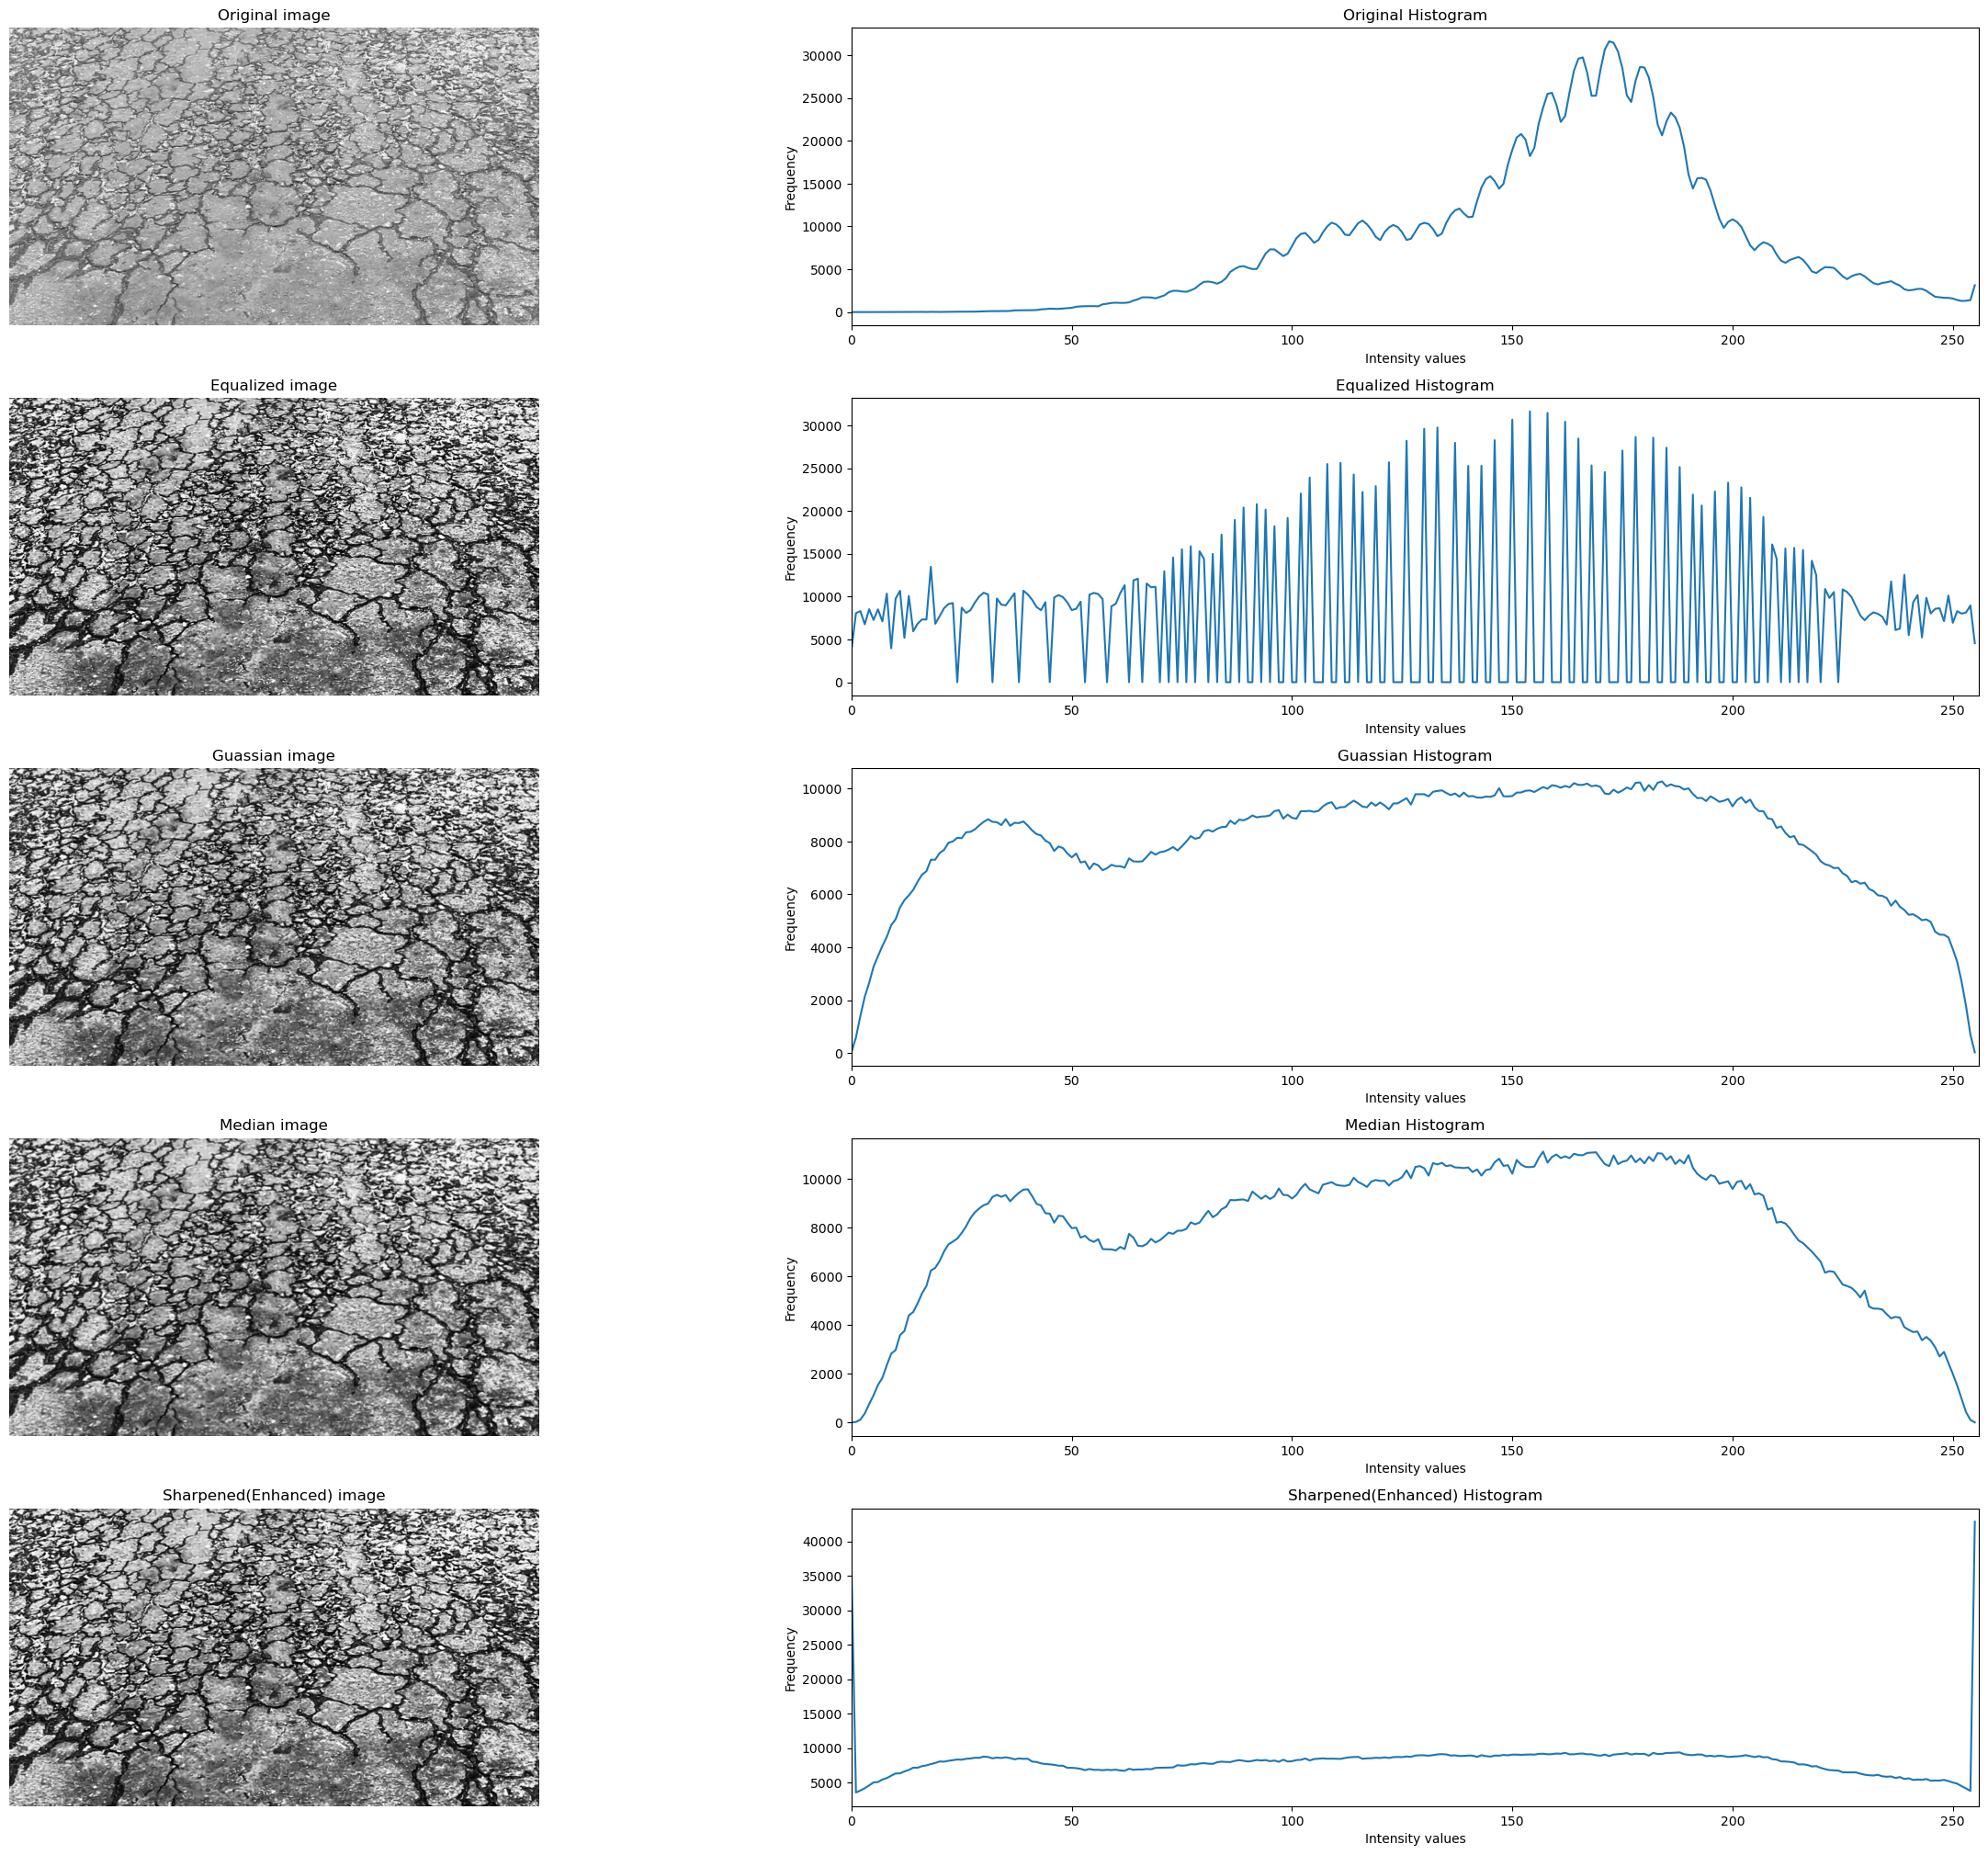

Output Display Completed.


In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

def histogram(image,title):
    histogram = cv2.calcHist([image],[0],None,[256],[0,256])

    plt.title(title)
    plt.xlabel("Intensity values")
    plt.ylabel("Frequency")
    plt.plot(histogram)
    plt.xlim([0,256])

# Input path
input_folder = "Frames"

# Final folder path
output_folder = "Enhanced_frames"

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Loop through all images
for filename in os.listdir(input_folder) :
    

        input_path = os.path.join(input_folder, filename)
    
        # read image and convert to gray scale
        img = cv2.imread(input_path, 0)

        # Enhancement part

        # Equalization Apply
        equalized = cv2.equalizeHist(img)

        # Noice Remoeval
        # Guassian Apply
        guassian = cv2.GaussianBlur(equalized,(5,5),1.0)
        # Median Apply
        median = cv2.medianBlur(guassian,(5))

        # Calculate Sharpness
        # convert image type (int to float) for appply laplacian 
        laplacian = cv2.Laplacian(median, cv2.CV_64F)

        # Apply sharpening
        sharpened = median - laplacian
        # Convert float image to int again for understand to the machine
        sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    
        plt.figure(figsize =(25,40))

    
        # Display Original Image 
        plt.subplot(10, 2, 1)
        plt.imshow(img, cmap='gray')
        plt.title("Original image")
        plt.axis('off')
    
        # Display Original Image Histogram
        plt.subplot(10,2,2)
        histogram(img,"Original Histogram")

    
        # Display Equalized Image
        plt.subplot(10, 2, 3)
        plt.imshow(equalized, cmap='gray')
        plt.title("Equalized image")
        plt.axis('off')
    
        # Display Equalized Image Histogram
        plt.subplot(10, 2, 4)
        histogram(equalized, "Equalized Histogram")

    
        # Display Equalized_Guassian Image
        plt.subplot(10,2,5)
        plt.imshow(guassian, cmap='gray')
        plt.title("Guassian image")
        plt.axis('off')
    
        # Display Equalized_Guassian Image Histogram
        plt.subplot(10,2,6)
        histogram(guassian,"Guassian Histogram")

    
        # Display Equalized_Guassianed_Median Image
        plt.subplot(10,2,7)
        plt.imshow(median, cmap='gray')
        plt.title("Median image")
        plt.axis('off')
    
        # Display Equalized_Guassianed_Median Image Histogram
        plt.subplot(10,2,8)
        histogram(median,"Median Histogram")

    
        # Display Equalized_Guassianed_Median_Sharpened Image
        plt.subplot(10,2,9)
        plt.imshow(sharpened, cmap='gray')
        plt.title("Sharpened(Enhanced) image")
        plt.axis("off")
    
        # Display Equalized_Guassianed_Median_Sharpened Image Histogram
        plt.subplot(10,2,10)
        histogram(sharpened,"Sharpened(Enhanced) Histogram")

    
        plt.tight_layout()
        plt.show()

        #Final output folder path
        cv2.imwrite(os.path.join(output_folder, f"{os.path.splitext(filename)[0]}_enhanced.png"), sharpened)
        
print("Output Display Completed.")